In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('./Downloads/games.csv')



df.columns = ['Name', 'Release date', 'Estimated owners', 'Peak CCU',
       'Required age', 'Price', 'Discount', 'DLC count', 'About the game',
       'Supported languages', 'Full audio languages', 'Reviews',
       'Header image', 'Website', 'Support url', 'Support email', 'Windows',
       'Mac', 'Linux', 'Metacritic score', 'Metacritic url', 'User score',
       'Positive', 'Negative', 'Score rank', 'Achievements', 'Recommendations',
       'Notes', 'Average playtime forever', 'Average playtime two weeks',
       'Median playtime forever', 'Median playtime two weeks', 'Developers',
       'Publishers', 'Categories', 'Genres', 'Tags', 'Screenshots', 'Movies']

In [3]:
inutiles = ["About the game", "Reviews", "Website", "Support url", "Support email", 
            "Metacritic url", "Notes", "Score rank", "Movies", "Header image", "Screenshots"]
df = df.drop(columns=inutiles)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 122611 entries, 2539430 to 4141790
Data columns (total 28 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Name                        122610 non-null  object 
 1   Release date                122611 non-null  object 
 2   Estimated owners            122611 non-null  object 
 3   Peak CCU                    122611 non-null  int64  
 4   Required age                122611 non-null  int64  
 5   Price                       122611 non-null  float64
 6   Discount                    122611 non-null  int64  
 7   DLC count                   122611 non-null  int64  
 8   Supported languages         122611 non-null  object 
 9   Full audio languages        122611 non-null  object 
 10  Windows                     122611 non-null  bool   
 11  Mac                         122611 non-null  bool   
 12  Linux                       122611 non-null  bool   
 13  Metacritic s

In [4]:
import re

def count_languages(row):
    langs = set()
    for col in ["Supported languages", "Full audio languages"]:
        val = str(row[col])
        # Extraire le contenu entre [ et ]
        matches = re.findall(r'\[([^\]]*)\]', val)
        for match in matches:
            if match.strip():
                # Compter les éléments par les virgules
                items = [x.strip().strip("'") for x in match.split(',')]
                langs.update(items)
    return len(langs)

df["Language Count"] = df.apply(count_languages, axis=1)

In [8]:
sum((df['Tags'].isna() & df['Genres'].isna() & df['Categories'].isna()) != 0)

7984

In [6]:
sum(df["Language Count"] == 0)

8380

In [10]:
sum(((df["Language Count"] == 0) + (df['Tags'].isna() & df['Genres'].isna() & df['Categories'].isna()) != 0) != 0)

8382

In [11]:
df = df[((df["Language Count"] == 0) + (df['Tags'].isna() & df['Genres'].isna() & df['Categories'].isna()) != 0) == 0]

In [12]:
df

,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,Supported languages,Full audio languages,...,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Language Count
496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,['English'],[],...,8,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",1
1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"['English', 'French', 'German', 'Russian']",[],...,0,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",4
3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,['Korean'],['Korean'],...,0,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,1
3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,['English'],['English'],...,0,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,1
1654170,Agony VR,"Apr 5, 2023",0 - 20000,0,0,13.99,0,0,"['English', 'French', 'Italian', 'German', 'Sp...","['English', 'Turkish']",...,0,0,0,0,Ignibit,"Ignibit,Madmind Studio","Single-player,Tracked Controller Support,VR On...","Action,Adventure",NaN,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4152910,完美传奇,"Jan 4, 2026",0 - 0,0,0,0.00,0,0,"['Simplified Chinese', 'Traditional Chinese']","['Simplified Chinese', 'Traditional Chinese']",...,0,0,0,0,完美传奇,完美传奇,"Single-player,Multi-player,MMO,PvP,Online PvP,...","Action,Adventure,Massively Multiplayer,RPG,Sim...",NaN,2
4042800,Poker Fate - ACG Texas Hold'em,"Jan 3, 2026",0 - 0,0,0,0.00,0,0,"['English', 'Japanese', 'Simplified Chinese', ...","['Japanese', 'Traditional Chinese']",...,0,0,0,0,©7 Points Digital Tech Limited,©7 Points Digital Tech Limited,"Multi-player,PvP,Online PvP,Cross-Platform Mul...","Casual,Strategy,Free To Play",NaN,4
3522550,Adira Nusantara,"Jan 3, 2026",0 - 0,0,0,7.99,0,0,['English'],['English'],...,0,0,0,0,Arraubi Gameware,Arraubi Gameware,"Single-player,Custom Volume Controls,Narrated ...","Action,Adventure,Casual,Early Access",NaN,1
3680350,A Lenda de Niterói,"Jan 4, 2026",0 - 0,0,0,2.09,0,0,"['Portuguese - Brazil', 'English']","['Portuguese - Brazil', 'English']",...,0,0,0,0,Seven Moons,Seven Moons,"Single-player,Full controller support,Family S...","Action,Adventure,Casual,Indie",NaN,2


# Création de la colonne TagGenre

In [25]:
def merge_and_clean(row):
    tags = str(row['Tags']).split(',') if pd.notna(row['Tags']) else[]
    genres = str(row['Genres']).split(',') if pd.notna(row['Genres']) else[] 
    
    tous_les_mots =[mot.strip() for mot in (tags + genres) if mot.strip()]
    mots_uniques = set(tous_les_mots)
    return ','.join(mots_uniques)
    
df2 = df.copy(deep = True)
combined_series = df2.apply(merge_and_clean, axis=1)
combined_dummies = combined_series.str.get_dummies(sep=',').astype(bool)
combined_dummies.columns =[f"TagGenre_{c}" for c in combined_dummies.columns]
df2 = pd.concat([df2, combined_dummies], axis=1)
print(df2.head())

                                          Name  Release date Estimated owners  \
496350   Supipara - Chapter 1 Spring Has Come!  Jul 29, 2016        0 - 20000   
1034400      Mystery Solitaire The Black Raven   May 6, 2019        0 - 20000   
3292190            버튜버 파라노이아 - Vtuber Paranoia  Oct 31, 2024        0 - 20000   
3631080                          Maze Quest VR  Apr 24, 2025        0 - 20000   
1654170                               Agony VR   Apr 5, 2023        0 - 20000   

         Peak CCU  Required age  Price  Discount  DLC count  \
496350          0             0   5.24        65          0   
1034400         0             0   4.99         0          0   
3292190         1             0   8.99         0          1   
3631080         0             0   4.99         0          0   
1654170         0             0  13.99         0          0   

                                       Supported languages  \
496350                                         ['English']   
1034400   

In [26]:
Optionels = ["Developers", "Publishers"]
df2 = df2.drop(columns=Optionels)
df2.info(verbose=all)

<class 'pandas.core.frame.DataFrame'>
Index: 114229 entries, 496350 to 4141790
Data columns (total 481 columns):
 #    Column                                      Dtype  
---   ------                                      -----  
 0    Name                                        object 
 1    Release date                                object 
 2    Estimated owners                            object 
 3    Peak CCU                                    int64  
 4    Required age                                int64  
 5    Price                                       float64
 6    Discount                                    int64  
 7    DLC count                                   int64  
 8    Supported languages                         object 
 9    Full audio languages                        object 
 10   Windows                                     bool   
 11   Mac                                         bool   
 12   Linux                                       bool   
 13   Metacritic 

In [27]:
Categories_dummies = df2['Categories'].str.get_dummies(sep=',').astype(bool)
Categories_dummies.columns = [f"Categories_{c.strip()}" for c in Categories_dummies.columns] # merci gemini
df2 = pd.concat([df2, Categories_dummies], axis=1)
print(df2.head())

                                          Name  Release date Estimated owners  \
496350   Supipara - Chapter 1 Spring Has Come!  Jul 29, 2016        0 - 20000   
1034400      Mystery Solitaire The Black Raven   May 6, 2019        0 - 20000   
3292190            버튜버 파라노이아 - Vtuber Paranoia  Oct 31, 2024        0 - 20000   
3631080                          Maze Quest VR  Apr 24, 2025        0 - 20000   
1654170                               Agony VR   Apr 5, 2023        0 - 20000   

         Peak CCU  Required age  Price  Discount  DLC count  \
496350          0             0   5.24        65          0   
1034400         0             0   4.99         0          0   
3292190         1             0   8.99         0          1   
3631080         0             0   4.99         0          0   
1654170         0             0  13.99         0          0   

                                       Supported languages  \
496350                                         ['English']   
1034400   

In [36]:
df3 = df2.copy(deep = True)
df3["Positive"] = np.log2(df3["Positive"] + 1)
df3["Negative"] = np.log2(df3["Negative"] + 1)
df3["Recommendations"] = np.log2(df3["Recommendations"] + 1)
df3["Average playtime forever"] = np.log2(df3["Average playtime forever"] + 1)
df3["Median playtime forever"] = np.log2(df3["Median playtime forever"] + 1)

# ACP

In [33]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [37]:
data_pca = df3.select_dtypes(include=["number", "int64"])
scaler = StandardScaler()
scaled_df3 = scaler.fit_transform(data_pca)
pca = PCA()
pca_df3 = pca.fit_transform(scaled_df3) 
explained_variance = pca.explained_variance_ratio_

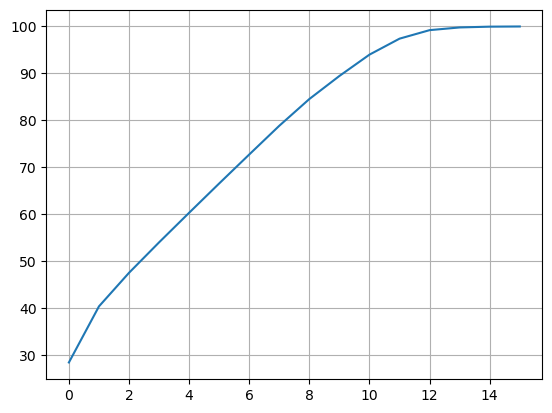

In [40]:
import matplotlib.pyplot as plt
plt.plot(pca.explained_variance_ratio_.cumsum() * 100)
plt.grid()
plt.show()